<a href="https://colab.research.google.com/github/LaraAlmani/IT326/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data Summarization and Preprocessing
**Dataset:** Student Performance Dataset (750 records, 15 attributes)  
**Class label:** `final_grade` (A, B, C, D, F)

The raw dataset is loaded into `raw_df` and never modified. All preprocessing is done on a copy (`df`), and the result `Preprocessed_dataset.csv`.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import micropip
await micropip.install("seaborn")
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")


raw_df = pd.read_csv("student_performance_dataset.csv")


df = raw_df.copy()

numeric_cols = ["age", "study_hours", "attendance_rate", "assignment_score",
                "midterm_score", "final_score", "sleep_hours", "stress_level"]
categorical_cols = ["gender", "internet_access", "parent_education",
                    "part_time_job", "extracurricular"]
target = "final_grade"

print("Shape:", raw_df.shape)
raw_df.head()

Shape: (750, 15)


,student_id,age,gender,study_hours,attendance_rate,assignment_score,midterm_score,final_score,internet_access,parent_education,sleep_hours,part_time_job,stress_level,extracurricular,final_grade
0,1,24,Female,3.06,69.94,82.42,66.39,81.68,No,PhD,7.48,Yes,2,Yes,B
1,2,21,Male,3.26,65.35,76.87,34.85,83.17,Yes,High School,6.87,Yes,6,No,F
2,3,22,Female,4.63,76.74,88.63,68.55,58.15,No,Bachelor,7.38,No,7,No,F
3,4,24,Female,3.42,91.61,66.68,83.50,79.49,Yes,High School,7.69,No,3,Yes,F
4,5,20,Male,2.15,83.29,73.93,70.08,74.38,Yes,Master,6.01,No,9,Yes,F


# 1. Data Analysis

## 1.1 Statistical Summaries

In [49]:
raw_df.info()
print()
raw_df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        750 non-null    int64  
 1   age               750 non-null    int64  
 2   gender            750 non-null    str    
 3   study_hours       750 non-null    float64
 4   attendance_rate   750 non-null    float64
 5   assignment_score  750 non-null    float64
 6   midterm_score     750 non-null    float64
 7   final_score       750 non-null    float64
 8   internet_access   750 non-null    str    
 9   parent_education  750 non-null    str    
 10  sleep_hours       750 non-null    float64
 11  part_time_job     750 non-null    str    
 12  stress_level      750 non-null    int64  
 13  extracurricular   750 non-null    str    
 14  final_grade       750 non-null    str    
dtypes: float64(6), int64(3), str(6)
memory usage: 70.4 KB



,count,mean,std,min,25%,50%,75%,max
student_id,750.0,375.500000,216.650640,1.00,188.2500,375.500,562.7500,750.00
age,750.0,20.950667,2.004393,18.00,19.0000,21.000,23.0000,24.00
study_hours,750.0,4.014920,1.568160,-1.35,3.0400,4.070,5.1100,8.71
attendance_rate,750.0,79.747587,11.703691,60.01,69.1175,79.730,89.9775,99.99
assignment_score,750.0,76.017907,10.370385,45.86,69.2000,76.445,82.6575,107.60
midterm_score,750.0,69.406987,11.775280,31.13,61.6925,69.660,77.3050,103.01
final_score,750.0,72.494853,14.585081,32.46,62.7600,72.415,82.4750,126.87
sleep_hours,750.0,7.030920,1.027692,3.87,6.3125,7.035,7.7300,9.77
stress_level,750.0,5.064000,2.559030,1.00,3.0000,5.000,7.0000,9.00


**Description:** `info()` shows the data types and `describe()` gives count, mean, std, min, quartiles and max for every numeric attribute.

**What it tells us:** Several values are impossible for this kind of data: `study_hours` has a negative minimum (-1.35), and `assignment_score`, `midterm_score` and `final_score` have maximums above 100 (107.6, 103.0 and 126.9). Also the attributes are on different scales (`attendance_rate` around 60-100, `stress_level` 1-9, `study_hours` around 0-9).  

**Decision:** The data needs noise/outlier treatment and normalization.

## 1.2 Missing Values Analysis

In [50]:
missing = pd.DataFrame({
    "missing_count": raw_df.isnull().sum(),
    "missing_percent": (raw_df.isnull().sum() / len(raw_df) * 100).round(2)
})
print(missing)
print()
print("Duplicated rows:", raw_df.duplicated().sum())

                  missing_count  missing_percent
student_id                    0              0.0
age                           0              0.0
gender                        0              0.0
study_hours                   0              0.0
attendance_rate               0              0.0
assignment_score              0              0.0
midterm_score                 0              0.0
final_score                   0              0.0
internet_access               0              0.0
parent_education              0              0.0
sleep_hours                   0              0.0
part_time_job                 0              0.0
stress_level                  0              0.0
extracurricular               0              0.0
final_grade                   0              0.0

Duplicated rows: 0


**Description:** Count and percentage of missing values per attribute, plus a check for duplicated rows.  
**What it tells us:** There are no missing values in any attribute and no duplicated rows.  
**Decision:** No imputation or row removal is needed.

## 1.3 Five Number Summary and Outliers (IQR method)

In [51]:
rows = []
for col in numeric_cols:
    q1 = raw_df[col].quantile(0.25)
    q3 = raw_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((raw_df[col] < lower) | (raw_df[col] > upper)).sum()
    rows.append([col, raw_df[col].min(), q1, raw_df[col].median(), q3,
                 raw_df[col].max(), round(lower, 2), round(upper, 2), n_out])

summary = pd.DataFrame(rows, columns=["attribute", "min", "Q1", "median", "Q3",
                                      "max", "lower_bound", "upper_bound", "outliers"])
summary

,attribute,min,Q1,median,Q3,max,lower_bound,upper_bound,outliers
0,age,18.00,19.0000,21.000,23.0000,24.00,13.00,29.00,0
1,study_hours,-1.35,3.0400,4.070,5.1100,8.71,-0.07,8.22,6
2,attendance_rate,60.01,69.1175,79.730,89.9775,99.99,37.83,121.27,0
3,assignment_score,45.86,69.2000,76.445,82.6575,107.60,49.01,102.84,7
4,midterm_score,31.13,61.6925,69.660,77.3050,103.01,38.27,100.72,7
5,final_score,32.46,62.7600,72.415,82.4750,126.87,33.19,112.05,3
6,sleep_hours,3.87,6.3125,7.035,7.7300,9.77,4.19,9.86,3
7,stress_level,1.00,3.0000,5.000,7.0000,9.00,-3.00,13.00,0


**Description:** The five-number summary shows the minimum, first quartile (Q1), median, third quartile (Q3), and maximum for each numerical attribute. The IQR method was also used to identify potential outliers.

**What it tells us:** Potential outliers were detected in `study_hours`, `assignment_score`, `midterm_score`, `final_score`, and `sleep_hours`. However, not all statistical outliers are necessarily invalid. Negative `study_hours` values and scores above 100 are domain-invalid, while extreme `sleep_hours` values may still be logically possible.

**Decision:** Preprocessing is required only for domain-invalid values, such as negative `study_hours` and scores above 100. Statistically extreme but logically valid values can be retained.

## 1.4 Boxplots (numeric attributes)

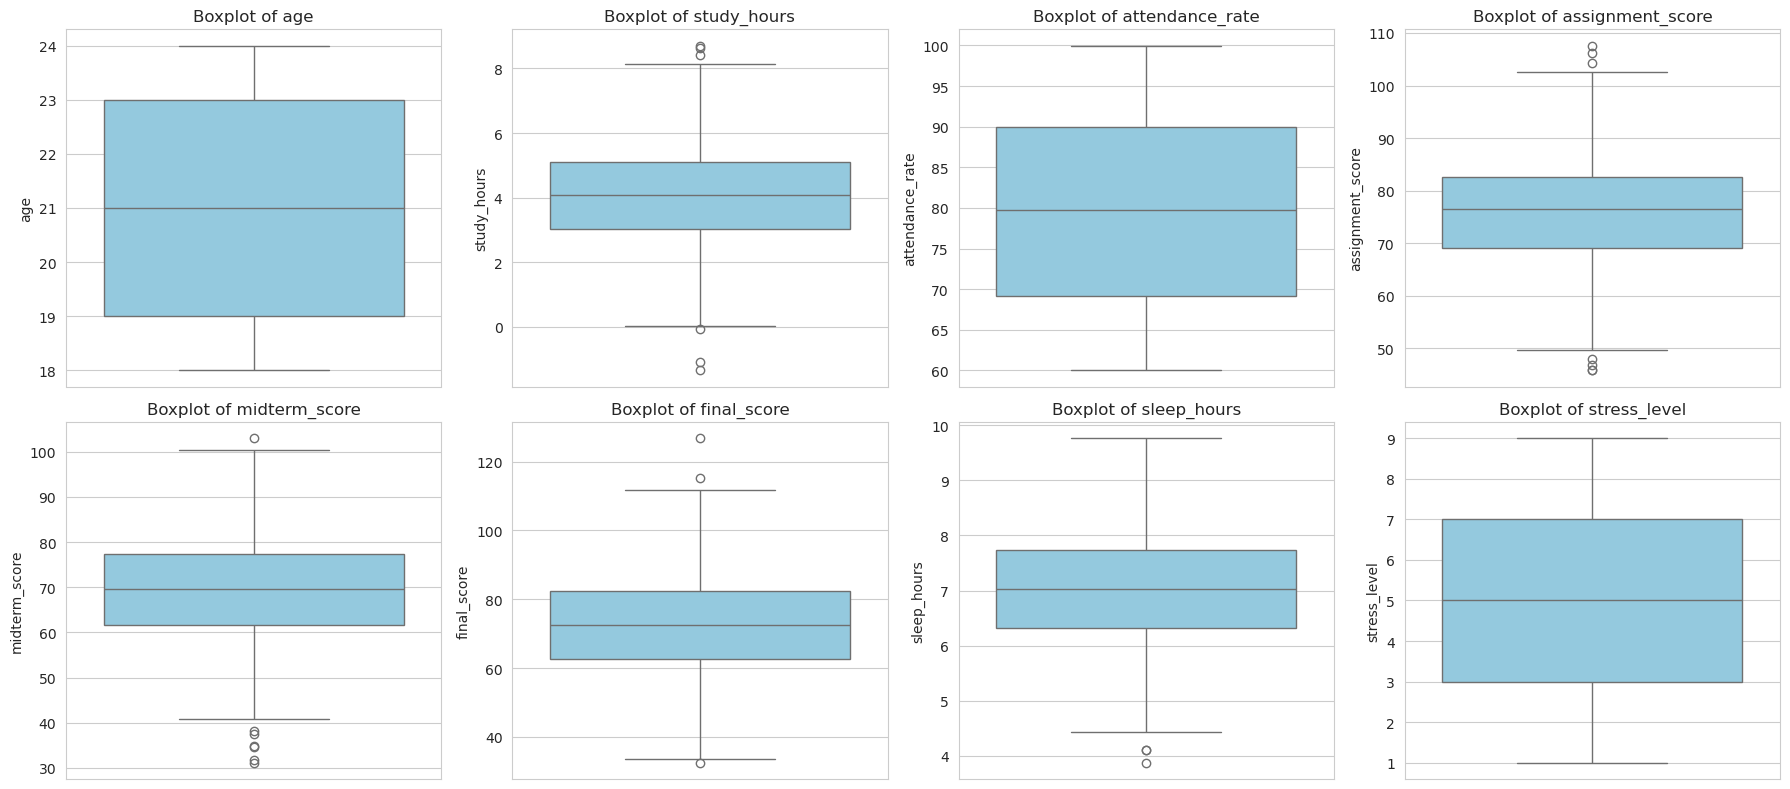

In [52]:
plot_cols = [
    "age", 
    "study_hours",
    "attendance_rate",
    "assignment_score",
    "midterm_score",
    "final_score",
    "sleep_hours",
    "stress_level"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(y=raw_df[col], ax=ax, color="skyblue")
    ax.set_title("Boxplot of " + col)

plt.tight_layout()
plt.show()

**Description:** Boxplots show the distribution of each numerical attribute using the median, quartiles, spread, and potential outliers.

**What it tells us:** The boxplots reveal potential outliers in several numerical attributes. Some values are domain-invalid, such as negative `study_hours` and scores above 100, while other extreme values may still be logically valid.

**Decision:** Domain-invalid values should be corrected using valid boundaries, while statistically extreme but logically valid values can be retained.

## 1.5 Histograms (variable distributions of numeric attributes)

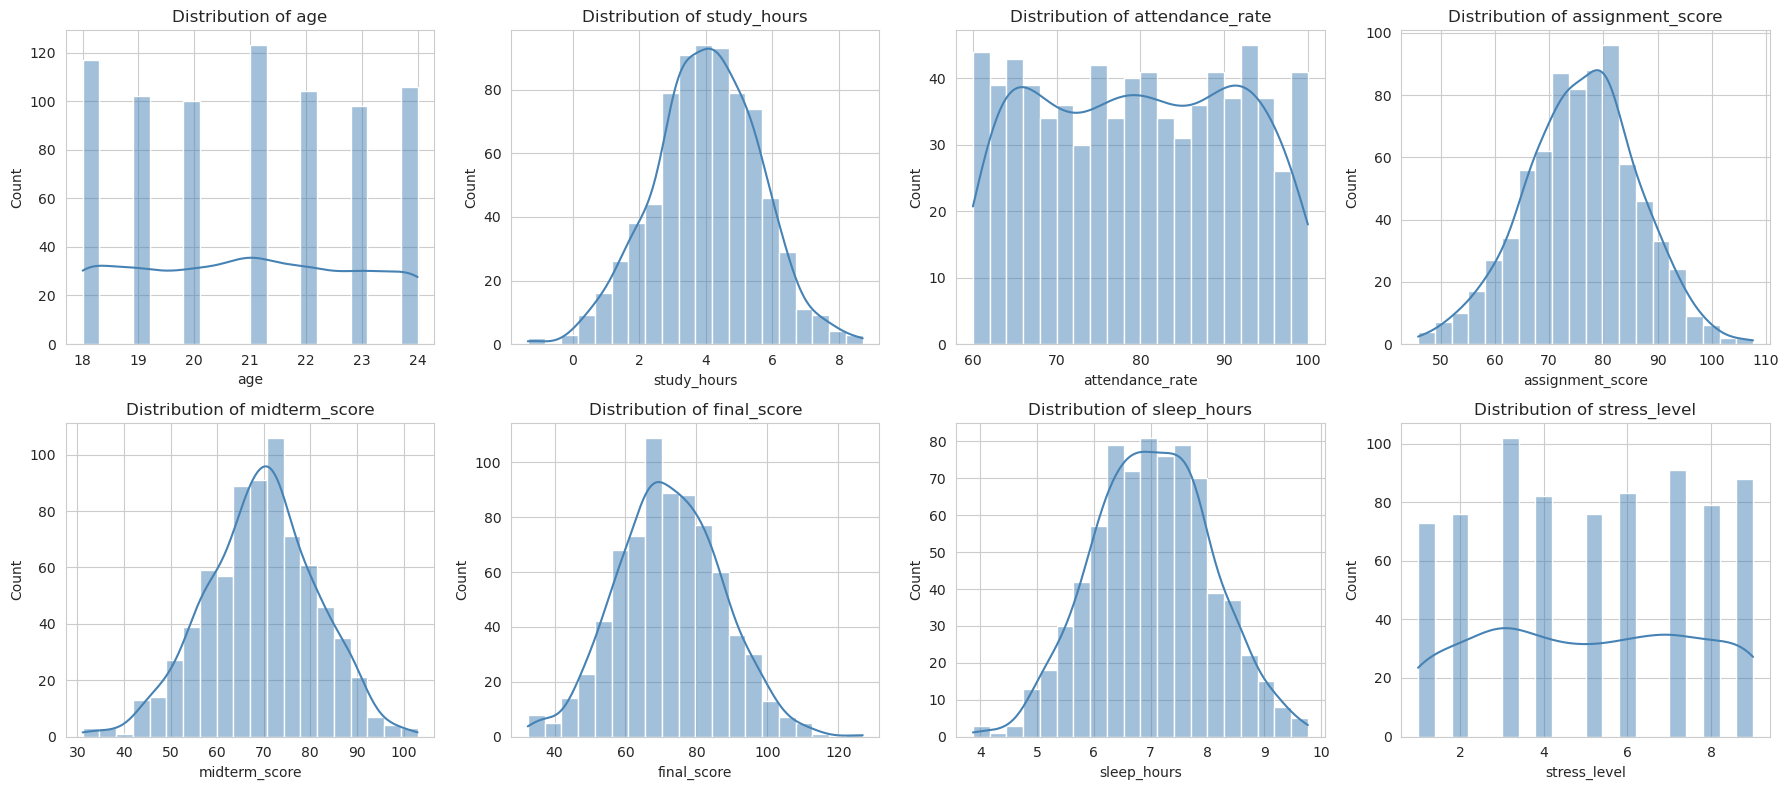

age                 0.02
study_hours        -0.09
attendance_rate     0.01
assignment_score   -0.11
midterm_score      -0.14
final_score         0.09
sleep_hours         0.01
stress_level        0.00
dtype: float64


In [53]:
hist_cols = ["age", "study_hours", "attendance_rate", "assignment_score",
             "midterm_score", "final_score", "sleep_hours", "stress_level"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), hist_cols):
    sns.histplot(raw_df[col], bins=20, kde=True, ax=ax, color="steelblue")
    ax.set_title("Distribution of " + col)
plt.tight_layout()
plt.show()

print(raw_df[hist_cols].skew().round(2))

**Description:** Histograms show the distribution of each numerical attribute, while the density curve and skewness values help describe the shape and symmetry of the distributions.

**What it tells us:** Most numerical attributes are approximately symmetric, with skewness values close to zero, so no skewness correction is needed. However, the numerical attributes have different ranges, and some score attributes contain extreme values beyond their valid limits.

**Decision:** Normalization is needed for selected numerical attributes with different ranges to place them on a common scale, while domain-invalid values are handled separately during noise removal.

## 1.6 Scatter Plots

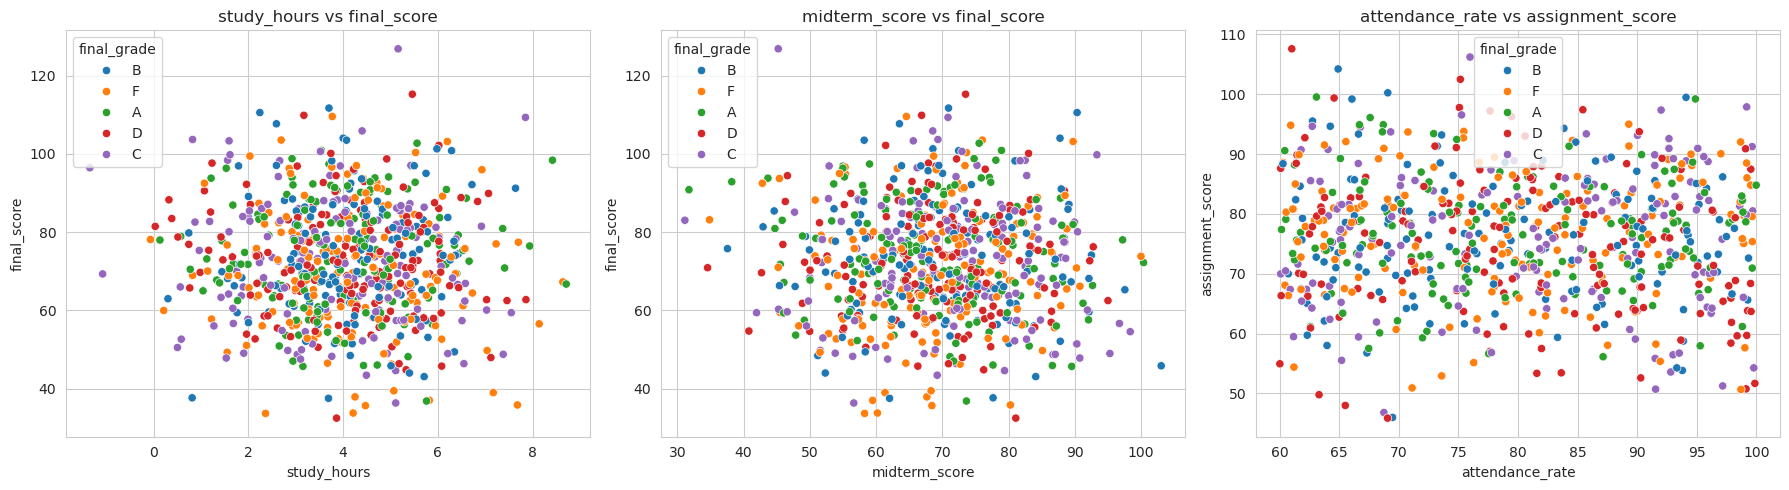

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=raw_df, x="study_hours", y="final_score", hue=target, ax=axes[0])
axes[0].set_title("study_hours vs final_score")
sns.scatterplot(data=raw_df, x="midterm_score", y="final_score", hue=target, ax=axes[1])
axes[1].set_title("midterm_score vs final_score")
sns.scatterplot(data=raw_df, x="attendance_rate", y="assignment_score", hue=target, ax=axes[2])
axes[2].set_title("attendance_rate vs assignment_score")
plt.tight_layout()
plt.show()

**Description:** Scatter plots of pairs of numeric attributes, coloured by the class label.  
**What it tells us:** The points are spread without a clear pattern (no strong linear relationship between the pairs), and the grade colours are mixed everywhere. The extreme points (negative `study_hours`, `final_score` above 100) are clearly separated from the main cloud.  
**Decision:** Confirms that the extreme points are noise that should be treated.

## 1.7 Bar Plots (nominal attributes)

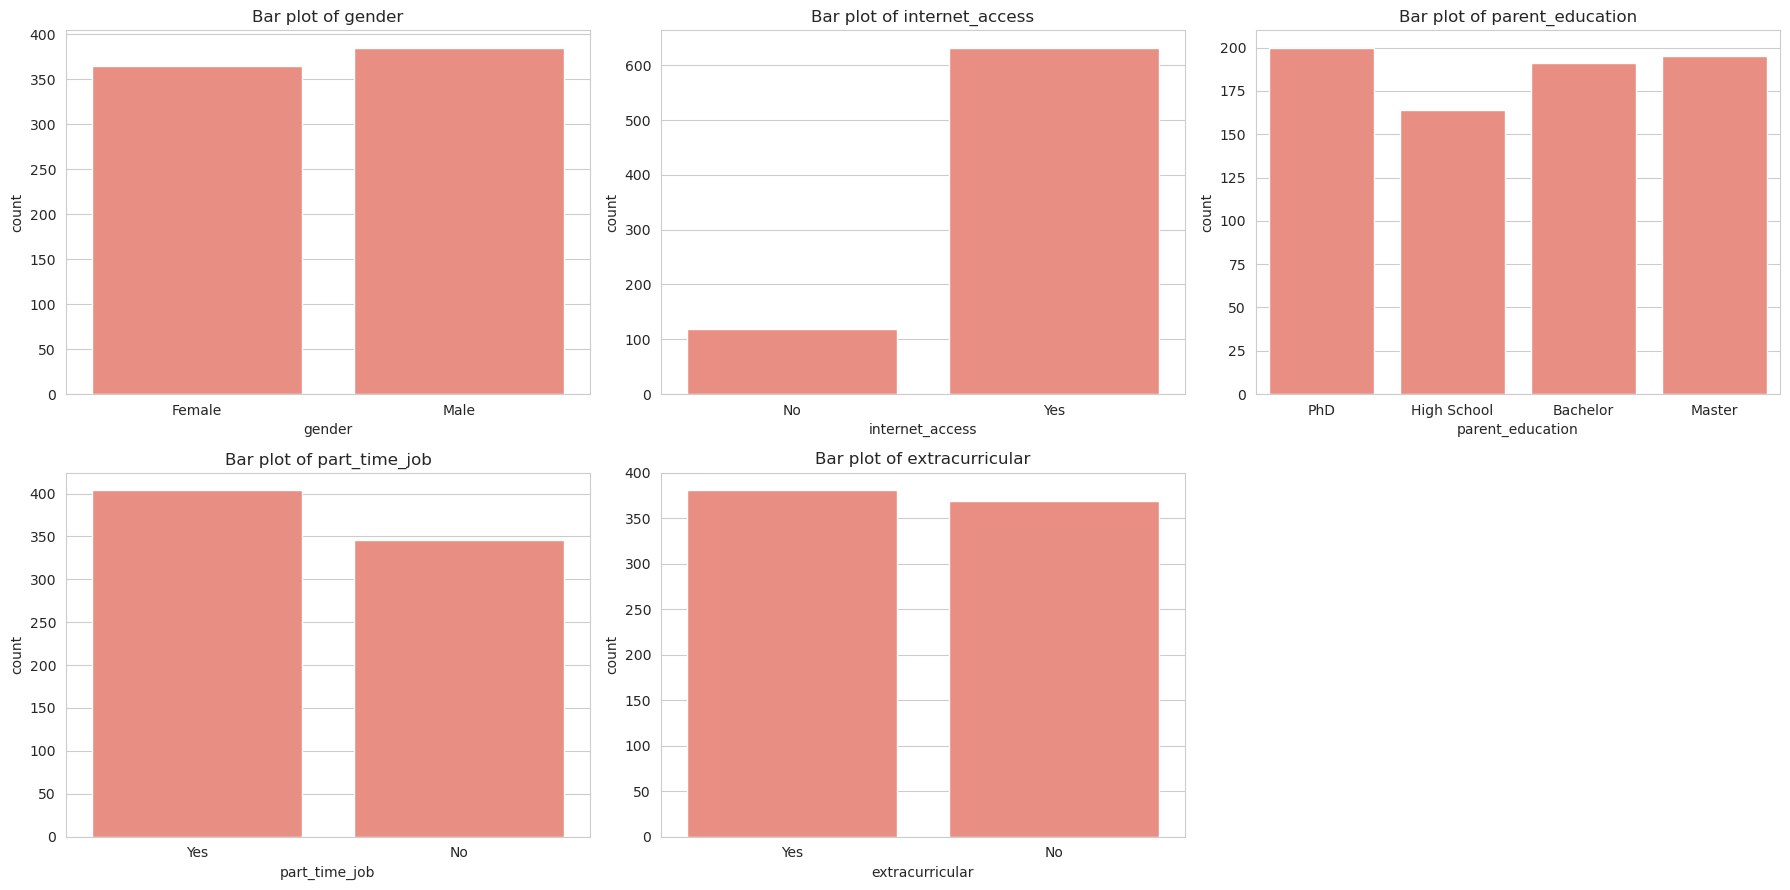

gender
Male      385
Female    365
Name: count, dtype: int64

internet_access
Yes    632
No     118
Name: count, dtype: int64

parent_education
PhD            200
Master         195
Bachelor       191
High School    164
Name: count, dtype: int64

part_time_job
Yes    404
No     346
Name: count, dtype: int64

extracurricular
Yes    381
No     369
Name: count, dtype: int64



In [55]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=raw_df, x=col, ax=ax, color="salmon")
    ax.set_title("Bar plot of " + col)
axes[1][2].axis("off")
plt.tight_layout()
plt.show()

for col in categorical_cols:
    print(raw_df[col].value_counts())
    print()

**Description:** Bar plots of the count of each category in the nominal attributes.  
**What it tells us:** The categories are fairly balanced, except `internet_access` (632 Yes vs 118 No). `gender`, `internet_access`, `part_time_job` and `extracurricular` have two values, and `parent_education` has four values (High School, Bachelor, Master, PhD) with a natural order. These attributes are stored as text.  
**Decision:** Categorical variable transformation is needed because the algorithms require numeric input.

## 1.8 Class Label Distribution

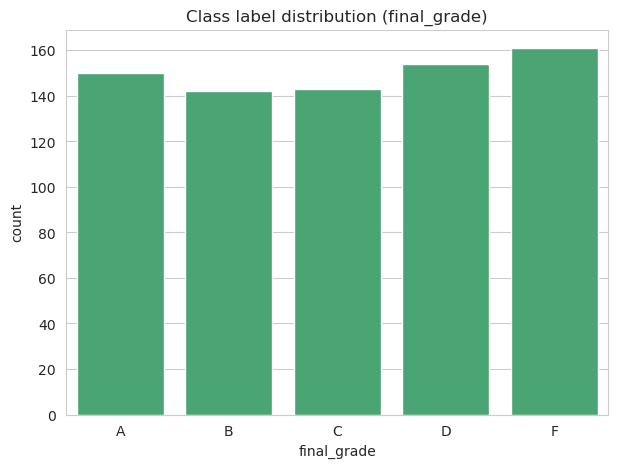

final_grade
A    150
B    142
C    143
D    154
F    161
Name: count, dtype: int64

final_grade
A    20.0
B    18.9
C    19.1
D    20.5
F    21.5
Name: proportion, dtype: float64


In [56]:
order = ["A", "B", "C", "D", "F"]
plt.figure(figsize=(7, 5))
sns.countplot(data=raw_df, x=target, order=order, color="mediumseagreen")
plt.title("Class label distribution (final_grade)")
plt.show()

print(raw_df[target].value_counts().reindex(order))
print()
print((raw_df[target].value_counts(normalize=True).reindex(order) * 100).round(1))

**Description:** Number of records in each class of `final_grade`.  
**What it tells us:** The five classes are almost balanced (A 150, B 142, C 143, D 154, F 161), so there is no class imbalance problem.  
**Decision:** No resampling is needed, and the original class distribution is preserved.

# 2. Data Preprocessing

According to the phase guidelines, we apply appropriate preprocessing tasks chosen from the recommended techniques: **Noise Removal**, **Discretization**, **Normalization** and **Variable Transformation (Categorical)**

## 2.1 Noise Removal

**Justification:** The attributes `study_hours`, `assignment_score`, `midterm_score`, and `final_score` contain domain-invalid values. Negative study hours and scores above 100 are not logically valid and may result from data entry errors or uncalibrated extra credit.

**Method:** Domain boundary clamping was applied by setting the lower threshold of `study_hours` to 0.0 and capping `assignment_score`, `midterm_score`, and `final_score` at 100.0.

**Improvement:** This corrects invalid values while preserving the relative ordering of students, avoiding unnecessary removal of records or replacement of valid extreme values.

In [57]:
print("--- Preprocessing: Noise Removal (Domain Boundary Clamping) ---")

df["study_hours"] = df["study_hours"].clip(lower=0.0)
for col in ["assignment_score", "midterm_score", "final_score"]:
  df[col] = df[col].clip(upper=100.0)

print("Updated ranges after domain boundary clamping:")
df[["study_hours", "assignment_score", "midterm_score", "final_score"]].describe().T[["min", "mean", "max"]]

--- Preprocessing: Noise Removal (Domain Boundary Clamping) ---
Updated ranges after domain boundary clamping:


,min,mean,max
study_hours,0.00,4.018253,8.71
assignment_score,45.86,75.990187,100.00
midterm_score,31.13,69.402507,100.00
final_score,32.46,72.312093,100.00


## 2.2 Discretization

**Justification:** `age` and `study_hours` were selected because they are numerical attributes that can be meaningfully grouped into categories, making the data easier to interpret and analyze.

**Method:** Discretization was applied using `pd.cut()` with three bins. `age` was divided into Young, Middle, and Older, while `study_hours` was divided into Low, Medium, and High.

**Improvement:** This transformation groups numerical values into categorical intervals, simplifying the data representation and making patterns in `age` and `study_hours` easier to analyze.

In [58]:
column_to_discretize = "age"
num_bins = 3
df["discretized_age"] = pd.cut(
    df[column_to_discretize],
    bins=num_bins,
    labels=["Young", "Middle", "Older"])
print("Original DataFrame:")
display(df[["age", "discretized_age"]].head(15))

Original DataFrame:


,age,discretized_age
0,24,Older
1,21,Middle
2,22,Middle
3,24,Older
4,20,Young
5,22,Middle
6,22,Middle
7,24,Older
8,19,Young
9,20,Young


In [59]:
column_to_discretize = "study_hours"
num_bins = 3
df["discretized_study_hours"] = pd.cut(
    df[column_to_discretize],
    bins=num_bins,
    labels=["Low", "Medium", "High"])
print("Original DataFrame:")
display(df[["study_hours", "discretized_study_hours"]].head(15))

Original DataFrame:


,study_hours,discretized_study_hours
0,3.06,Medium
1,3.26,Medium
2,4.63,Medium
3,3.42,Medium
4,2.15,Low
5,2.35,Low
6,4.81,Medium
7,1.96,Low
8,6.10,High
9,2.96,Medium


## 2.3 Variable Transformation (Categorical)

**Justification:** Machine learning algorithms require numerical inputs and cannot directly perform mathematical operations on textual categorical data such as `gender`, `internet_access`, `parent_education`, `part_time_job`, `extracurricular`, and `final_grade`.

**Method:** Binary mapping (0/1) was applied to the two-category nominal attributes `gender`, `internet_access`, `part_time_job`, and `extracurricular`. Ordinal mapping was applied to `parent_education` (0 to 3) and `final_grade` (0 to 4) to preserve their natural order.

**Improvement:** This transformation converts categorical attributes into numerical formats compatible with data mining methods while preserving the meaningful order of education levels and letter grades without adding unnecessary columns.

In [60]:
# 1. Binary nominal 
df['gender_transformed'] = df['gender'].replace({'Female': 1, 'Male': 0})
df['internet_access_transformed'] = df['internet_access'].replace({'Yes': 1, 'No': 0})
df['part_time_job_transformed'] = df['part_time_job'].replace({'Yes': 1, 'No': 0})
df['extracurricular_transformed'] = df['extracurricular'].replace({'Yes': 1, 'No': 0})
# 2. Ordinal variable
df['parent_education_transformed'] = df['parent_education'].replace({'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3})
# 3. Target class label mapped to standard academic grade order
df['final_grade_transformed'] = df['final_grade'].replace({'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4})

display(df[[
    'gender', 'gender_transformed',
    'parent_education', 'parent_education_transformed',
    'internet_access','internet_access_transformed',
    'part_time_job', 'part_time_job_transformed' ,
    'extracurricular' , 'extracurricular_transformed',
    'final_grade', 'final_grade_transformed'
]].head(5))

,gender,gender_transformed,parent_education,parent_education_transformed,internet_access,internet_access_transformed,part_time_job,part_time_job_transformed,extracurricular,extracurricular_transformed,final_grade,final_grade_transformed
0,Female,1,PhD,3,No,0,Yes,1,Yes,1,B,3
1,Male,0,High School,0,Yes,1,Yes,1,No,0,F,0
2,Female,1,Bachelor,1,No,0,No,0,No,0,F,0
3,Female,1,High School,0,Yes,1,No,0,Yes,1,F,0
4,Male,0,Master,2,Yes,1,No,0,Yes,1,F,0


## 2.4 Normalization

**Justification:** The selected numerical attributes (`attendance_rate`, `assignment_score`, `midterm_score`, `final_score`, and `stress_level`) have different numerical ranges. Normalization is applied to place these attributes on a common scale and prevent attributes with larger ranges from having a greater influence on distance-based analysis.

**Method:** Min-Max normalization was applied to `attendance_rate`, `assignment_score`, `midterm_score`, `final_score`, and `stress_level`, transforming their values to the range [0, 1]. The attributes `student_id`, `age`, `study_hours`, and `sleep_hours` were excluded from normalization, along with categorical attributes and the target variable `final_grade`.

**Improvement:** The selected numerical attributes are now represented on the same scale, reducing the effect of differences in their original ranges. This improves their suitability for distance-based data mining methods such as clustering.

In [61]:
# Numerical attributes selected for normalization
cols_to_normalize = [
    "attendance_rate",
    "assignment_score",
    "midterm_score",
    "final_score",
    "stress_level"
]

# Check ranges before normalization
print("Numeric attribute ranges before normalization:")
df[cols_to_normalize].agg(["min", "max"]).T

Numeric attribute ranges before normalization:


,min,max
attendance_rate,60.01,99.99
assignment_score,45.86,100.00
midterm_score,31.13,100.00
final_score,32.46,100.00
stress_level,1.00,9.00


In [62]:
# Apply Min-Max normalization
scaler = MinMaxScaler()

df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print("Ranges after Min-Max normalization:")
df[cols_to_normalize].agg(["min", "max"]).T

Ranges after Min-Max normalization:


,min,max
attendance_rate,0.0,1.0
assignment_score,0.0,1.0
midterm_score,0.0,1.0
final_score,0.0,1.0
stress_level,0.0,1.0


In [63]:
# Check that the raw data was not modified
raw_check = pd.read_csv("student_performance_dataset.csv")
print("Raw data unchanged:", raw_df.equals(raw_check))

print("Preprocessed Dataset:")
display(df.head())

df.to_csv("Preprocessed_dataset.csv", index=False)

print("Preprocessed dataset saved successfully!")
print("Final shape:", df.shape)

Raw data unchanged: True
Preprocessed Dataset:


,student_id,age,gender,study_hours,attendance_rate,assignment_score,midterm_score,final_score,internet_access,parent_education,...,extracurricular,final_grade,discretized_age,discretized_study_hours,gender_transformed,internet_access_transformed,part_time_job_transformed,extracurricular_transformed,parent_education_transformed,final_grade_transformed
0,1,24,Female,3.06,0.248374,0.675286,0.511979,0.728753,No,PhD,...,Yes,B,Older,Medium,1,0,1,1,3,3
1,2,21,Male,3.26,0.133567,0.572774,0.054015,0.750814,Yes,High School,...,No,F,Middle,Medium,0,1,1,0,0,0
2,3,22,Female,4.63,0.418459,0.789989,0.543343,0.380367,No,Bachelor,...,No,F,Middle,Medium,1,0,0,0,1,0
3,4,24,Female,3.42,0.790395,0.384559,0.760418,0.696328,Yes,High School,...,Yes,F,Older,Medium,1,1,0,1,0,0
4,5,20,Male,2.15,0.582291,0.518471,0.565558,0.620669,Yes,Master,...,Yes,F,Young,Low,0,1,0,1,2,0


Preprocessed dataset saved successfully!
Final shape: (750, 23)
